In [1]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist


In [2]:
#load
X= np.load('data/f1/updated_inputs.npy')
y= np.load('data/f1/updated_outputs.npy')    # keep original sign
y= np.absolute(y) #absolute value

In [3]:
# Data verification
print (X)
print(y)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.524649   0.520751  ]]
[1.32267704e-079 1.03307824e-046 7.71087511e-016 3.34177101e-124
 3.60606264e-003 2.15924904e-054 2.08909327e-091 2.53500115e-040
 3.60677119e-081 6.22985647e-048 2.20789189e-015]


In [4]:
#statidistic data
y_mean_val = np.mean(y)
y_std_val  = np.std(y)

#Normalization
y_norm = (y - y_mean_val) / y_std_val if y_std_val > 0 else y

print(f"Data Standard Deviation is: {y_std_val:.6f}")
print (y_norm)

Data Standard Deviation is: 0.001037
[-0.31622777 -0.31622777 -0.31622777 -0.31622777  3.16227766 -0.31622777
 -0.31622777 -0.31622777 -0.31622777 -0.31622777 -0.31622777]


In [5]:
# The best
best_f = np.max(y_norm)
best_idx = np.argmax(y_norm)
print(f"the best data is: X = {X[best_idx]}, y_norm = {best_f:.4f}")

the best data is: X = [0.65011406 0.68152635], y_norm = 3.1623


In [6]:
# Compute distance for RBF lengthscale
distances = pdist(X, metric='euclidean')   # compute mean distance between data
print('Distance:', distances.mean())

Distance: 0.4826080465204496


In [7]:
#GP Model
noise_assumption = 1e-2 # moderate noise
rbf_lengthscale  = .25*distances.mean()    #first attempt with 50% of mean distance

kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model  = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
model.fit(X, y_norm)

,kernel,RBF(length_scale=0.121)
,alpha,0.01
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__length_scale,np.float64(0.1206520116301124)
,kernel__length_scale_bounds,'fixed'


In [8]:
# Grid 2D for prediction
n_grid   = 100
x1_range = np.linspace(X[:,0].min(), X[:,0].max(), n_grid)
x2_range = np.linspace(X[:,1].min(), X[:,1].max(), n_grid)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
x_grid_2d = np.column_stack([xx1.ravel(), xx2.ravel()])

In [9]:
#GP Prediction
post_mean, post_std = model.predict(x_grid_2d, return_std=True)

In [10]:
###  New adquisition Function EI (same GP)

In [11]:
def expected_improvement(mean, std, best_f, xi=0.01):
    Z  = (mean - best_f - xi) / (std + 1e-9)
    ei = (mean - best_f - xi) * norm.cdf(Z) + std * norm.pdf(Z)
    ei[std <= 0.0] = 0.0
    return ei

ei_values = expected_improvement(post_mean, post_std, best_f, xi=0.01)

In [12]:
# Calculate the maximum value
idx_next = np.argmax(ei_values)
x_next   = x_grid_2d[idx_next]
std_next = post_std[idx_next]
y_next = post_mean[idx_next]

print(f"proposed query(EI): x1={x_next[0]:.6f}, x2={x_next[1]:.8f},y_norm = {best_f:.4f}")
print(f"proposed query std (EI): {std_next:.6f}")
print(f"proposed query y_next (EI): {y_next:.6f}")

#best from EI
x_next_ei = x_next
y_next_ei = y_next

proposed query(EI): x1=0.608668, x2=0.66139574,y_norm = 3.1623
proposed query std (EI): 0.253856
proposed query y_next (EI): 3.582063


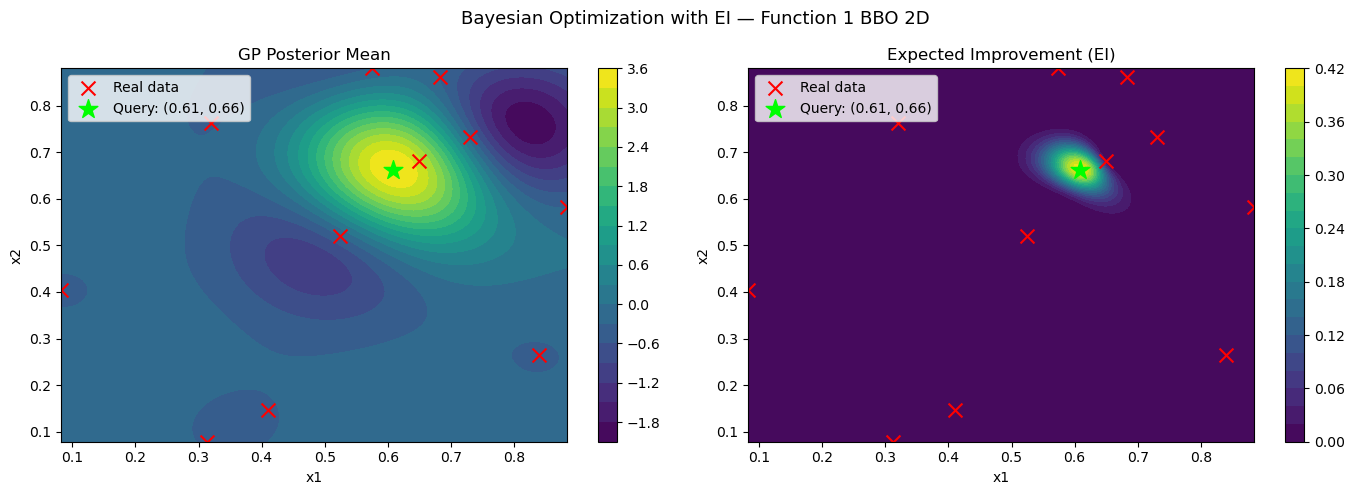

In [13]:
#graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, values, title in zip(axes,
    [post_mean, ei_values],
    ['GP Posterior Mean', 'Expected Improvement (EI)']):

    Z_plot = values.reshape(n_grid, n_grid)
    cp = ax.contourf(xx1, xx2, Z_plot, levels=20, cmap='viridis')
    fig.colorbar(cp, ax=ax)
    ax.scatter(X[:,0], X[:,1], c='red', marker='x', s=100, label='Real data')
    ax.scatter(x_next[0], x_next[1], c='lime', marker='*', s=200, zorder=5, label=f'Query: ({x_next[0]:.2f}, {x_next[1]:.2f})')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Bayesian Optimization with EI — Function 1 BBO 2D', fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
    ## New adquisition Function UCB (same GP)

In [15]:
#UCB (maximize)
k = 1 #exploitation focus
acquisition = post_mean + k * post_std
idx_next = np.argmax(acquisition)
x_next = x_grid_2d[idx_next]
std_next = post_std[idx_next]
y_next = post_mean[idx_next]

print(f"Proposed query (UCB): x1={x_next[0]:.8f}, x2={x_next[1]:.8f},y_norm = {best_f:.4f}")
print(f"proposed query std (UCB): {std_next:.6f}")
print(f"proposed query y_next (UCB): {y_next:.6f}")

#best from UCB
x_next_ucb = x_next
y_next_ucb = y_next

Proposed query (UCB): x1=0.59247798, x2=0.66948842,y_norm = 3.1623
proposed query std (UCB): 0.344334
proposed query y_next (UCB): 3.523917


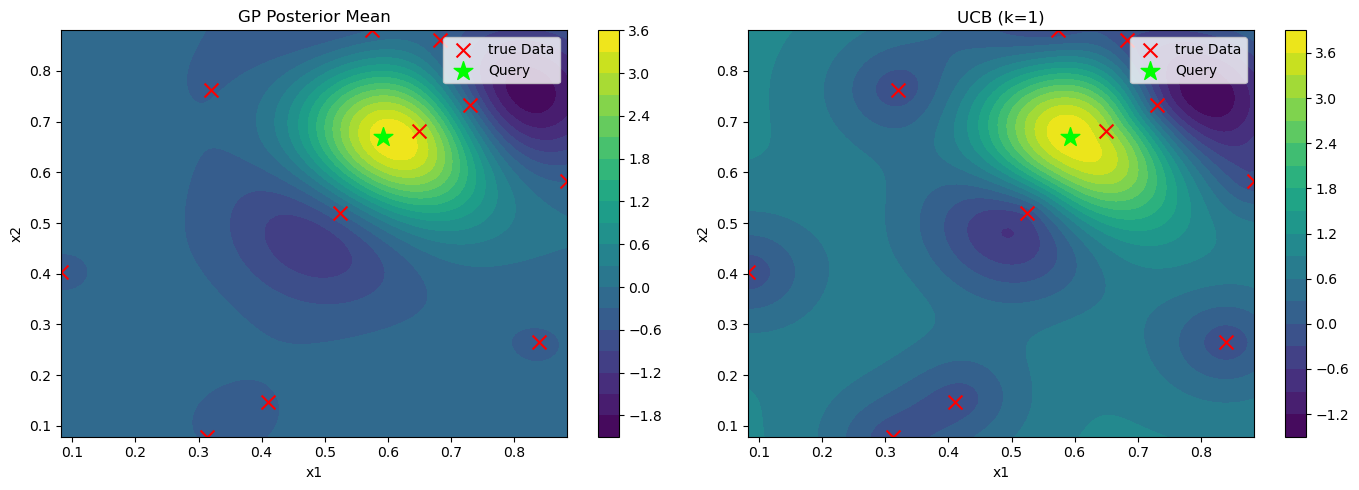

In [16]:
# Graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, values, title in zip(axes,
    [post_mean, acquisition],
    ['GP Posterior Mean', f'UCB (k={k})']):
    
    Z = values.reshape(n_grid, n_grid)
    cp = ax.contourf(xx1, xx2, Z, levels=20, cmap='viridis')
    fig.colorbar(cp, ax=ax)
    ax.scatter(X[:,0], X[:,1], c='red', marker='x', s=100, label='true Data')
    ax.scatter(x_next[0], x_next[1], c='lime', marker='*', s=200, label='Query')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

In [17]:
# Choose the best option between EI and UCB
if y_next_ei > y_next_ucb:
    x_next_out = x_next_ei
else:
    x_next_out = x_next_ucb

# Write output file
import os
folder = 'results'
filename = 'output_F1.txt'
file_path = os.path.join(folder, filename)
with open(file_path, 'w', encoding='utf-8') as f:
    f.write(f"{x_next_out[0]:.6f} {x_next_out[1]:.6f}\n")